In [8]:
import numpy as np
import matplotlib.pyplot as plt

def build_ky_hamiltonian(t, V, ky, a, k,Bz):
    #A=(0,Bx,0)
    H_matrix = np.zeros((k, k), dtype=complex)
    for i in range(k):
        if i == 0:
            H_matrix[i, i] = V + 2*t*np.cos(ky*a)  
            H_matrix[i, i+1] = 1*t*np.exp(1j*0.5*Bz*a**2)
        elif i == k-1:
            H_matrix[i, i-1] = 1*t*np.exp(-1j*0.5*Bz*a**2)
            H_matrix[i, i] = V + 2*t*np.cos(ky*a)  
        else:  
            H_matrix[i, i-1] = 1*t*np.exp(-1j*0.5*Bz*a**2)
            H_matrix[i, i] = V + 2*t*np.cos(ky*a)  
            H_matrix[i, i+1] = 1*t*np.exp(1j*0.5*Bz*a**2)
    return H_matrix

def calculate_band_structure(t, V, a, k, ky_points,Bz):
    ky_set = np.linspace(-np.pi/a, np.pi/a, ky_points)
    eigenvalues_all = [[] for _ in range(k)]
    for ky in ky_set:
        H_matrix = build_ky_hamiltonian(t, V, ky, a, k,Bz)
        eigenvalues = np.linalg.eigvals(H_matrix)
        eigenvalues_sorted = sorted(eigenvalues, key=lambda x: x.real)  
        for band_idx in range(k):
            eigenvalues_all[band_idx].append(eigenvalues_sorted[band_idx].real)
    return ky_set, eigenvalues_all

def plot_band_structure(ky_set, eigenvalues_all):
    plt.figure(figsize=(10, 6))
    
    for band_idx, band_energies in enumerate(eigenvalues_all):
        plt.plot(ky_set, band_energies, color='red', linewidth=2)
    
    plt.xlabel('ky', fontsize=14)
    plt.ylabel('E', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

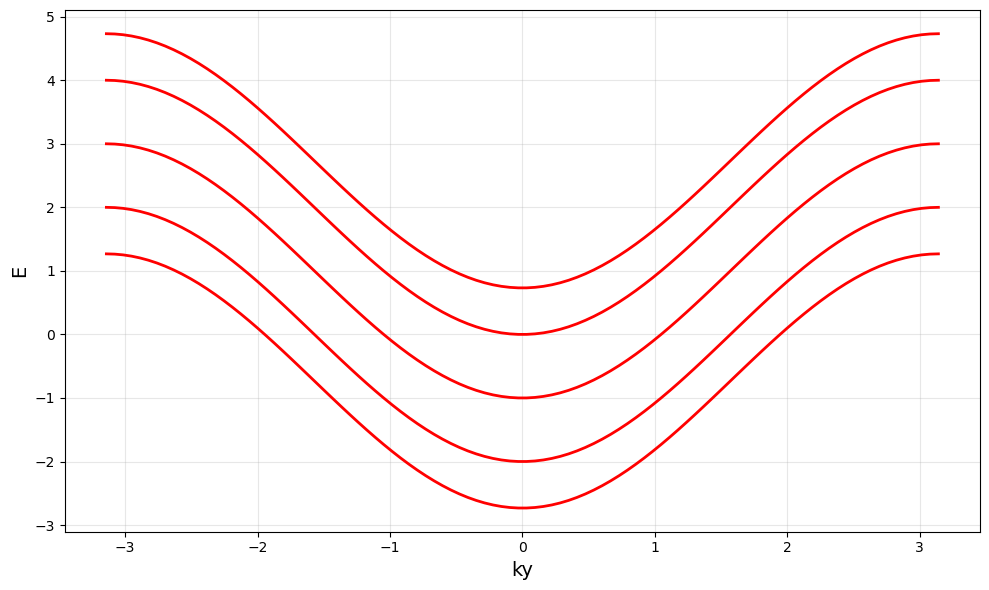

In [10]:
if __name__ == "__main__":
    t=-1
    V=1
    a=1
    k=5
    ky_points=100
    Bz=0.1
    ky_set, eigenvalues_all = calculate_band_structure(t, V, a, k, ky_points,Bz)
    plot_band_structure(ky_set, eigenvalues_all)